##### ***多头注意力***
###### 当给定同一组查询、键值对时，我们希望模型可以基于同种注意力机制，但是学习到不同的表示，以获得更丰富的信息。因此允许注意力机制组合使用查询、键值对的不同子空间表示，可能是有益的。所以与其只用一个注意力汇聚，不如尝试使用多个注意力机制的汇聚。所以我们可以用独立学习得到的h组不同的线性投影来交换查询、键、值。然后将h组变换后的查询、键、值并行的输入到注意力汇聚中，最后将这h个注意力汇聚的输出拼接在一起，并且通过另一个可以学习的线性投影进行变换，得到最终输出。这就是多头注意力。具体架构如下图：
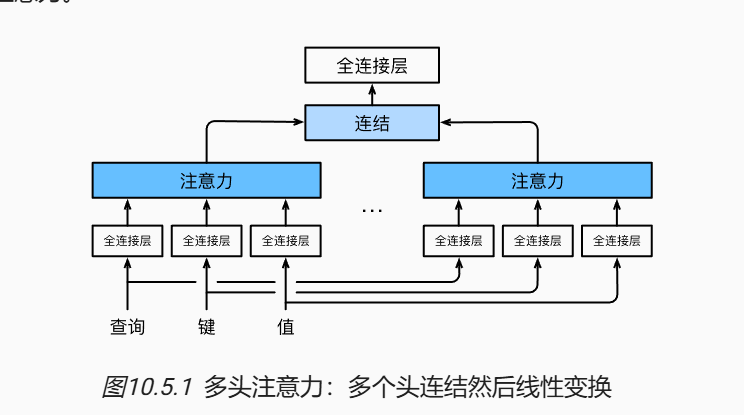
##### ***多头注意力模型***
###### 首先我们利用数学语言将其描述出来。给定查询$q\in\mathbb{R}^{d_q}$，键$k\in\mathbb{R}^{d_k}$，值$v\in\mathbb{R}^{d_v}$，每个注意力头$h_i$的计算方法为：
$$h_i = f(W_i^{(q)}q, W_i^{(k)}k, W_i^{(v)}v)\in\mathbb{R}^{p_v}$$
###### 其中，$W_i^{(q)}$、$W_i^{(k)}$、$W_i^{(v)}$是可学习的线性投影矩阵，$f$是注意力汇聚函数，可以是加性注意力或者缩放点积注意力。之后，多头注意力的输出需要经过另一个线性转换，它对应着h个头连结后的结果，可学习参数是$W_o\in\mathbb{R}^{p_o\times hp_v}$:
$$W_o = 
\begin{bmatrix}
h_1\\
\vdots\\
h_h\\
\end{bmatrix}
\in\mathbb{R}^{p_o}.
$$

In [1]:
import torch
from torch import nn
from d2l import torch as d2l
import math

###### 在具体实现中，通常选择缩放点积注意力作为每一个注意力头，同时为了避免计算代价和参数代价的大幅增长，我们设定$p_q = p_k = p_v = p_o/h$，也就是说每个头只负责整个输出维度的一部分，这样一来总计算量和单头维度就是同一量级了。值得注意的是，如果我们将查询、键、值的输出数量设置成$p_qh = p_kh = p_vh = p_o$，那我们其实可以并行计算h个头。也就是说计算的时候会得到输出维度为$p_qh$，然后我们将其拆分为h个块，相当于并行做h次注意力

In [3]:
class MultiHeadAttention(nn.Module):
    """多头注意力"""
    def __init__(self, key_size, query_size, value_size, num_hiddens, num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = d2l.DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)
    
    def forward(self, queries, keys, values, valid_lens):
        # queries, keys, values的形状:(batch_size, num_queries/keys/values, query/key/value_size)
        # valid_lens的形状:(batch_size, num_queries/keys/values)
        # 经过变换后，输出的queries, keys, values的形状:(batch_size*num_heads, num_queries/keys/values, num_hiddens/num_heads)
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)

        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, repeats=self.num_heads, dim=0)
        
        # output的形状:(batch_size*num_heads, num_queries/keys/values, num_hiddens/num_heads)
        output = self.attention(queries, keys, values, valid_lens)

        # output_concat的形状:(batch_size，查询的个数，num_hiddens)
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)


In [4]:
def transpose_qkv(X, num_heads):
    """为了多头注意力的并行计算而变换形状"""
    # 输入x的形状是(batch_size, num_queries/keys/values, num_hiddens)
    # 输出的形状是(batch_size*num_heads, num_queries/keys/values,num_heads, num_hiddens/num_heads)
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)

    # 交换头和查询键值对的维度
    X = X.permute(0, 2, 1, 3)

    # 最终输出的形状：(batch_size*num_heads, num_queries/keys/values, num_hiddens/num_heads)
    return X.reshape(-1, X.shape[2], X.shape[3])

def transpose_output(X, num_heads):
    """逆转transpose_qkv函数的操作"""
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X=  X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)


In [5]:
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens,
                               num_hiddens, num_heads, 0.5)
attention.eval()

MultiHeadAttention(
  (attention): DotProductAttention(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (W_q): Linear(in_features=100, out_features=100, bias=False)
  (W_k): Linear(in_features=100, out_features=100, bias=False)
  (W_v): Linear(in_features=100, out_features=100, bias=False)
  (W_o): Linear(in_features=100, out_features=100, bias=False)
)

In [6]:
batch_size, num_queries = 2, 4
num_kvpairs, valid_lens =  6, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))
attention(X, Y, Y, valid_lens).shape

torch.Size([2, 4, 100])